In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("/content/social_media_personality_dataset_with_mood_balanced.csv")

# Select and clean relevant columns
cols = ['Age', 'Gender', 'Likes_per_Post', 'Comments_per_Post', 'Shares_per_Post',
        'Mentions_per_Post', 'Personality_Type', 'Mood']
df = df[cols]
df = df[df['Personality_Type'].isin(['Introvert', 'Extrovert', 'Normal'])]
df = df[df['Mood'].isin(['Happy', 'Neutral', 'Sad'])]
df = df.dropna()

# Encode categorical variables
le_personality = LabelEncoder()
df['Personality_Label'] = le_personality.fit_transform(df['Personality_Type'])

le_mood = LabelEncoder()
df['Mood_Label'] = le_mood.fit_transform(df['Mood'])

# One-hot encode Gender
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# Features and targets
X = df.drop(['Personality_Type', 'Personality_Label', 'Mood', 'Mood_Label'], axis=1)
y_personality = df['Personality_Label']
y_mood = df['Mood_Label']

# Train-test split
X_train, X_test, y_train_personality, y_test_personality = train_test_split(X, y_personality, test_size=0.2, random_state=42)
_, _, y_train_mood, y_test_mood = train_test_split(X, y_mood, test_size=0.2, random_state=42)

# Train models
model_personality = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42)
model_personality.fit(X_train, y_train_personality)

model_mood = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42)
model_mood.fit(X_train, y_train_mood)

# Evaluate models
print("Personality Classification Report:\n", classification_report(y_test_personality, model_personality.predict(X_test), target_names=le_personality.classes_))
print("Mood Classification Report:\n", classification_report(y_test_mood, model_mood.predict(X_test), target_names=le_mood.classes_))


# Function to predict personality and mood
def predict_user(age, gender, likes, comments, shares, mentions):
    input_df = pd.DataFrame([{
        'Age': age,
        'Likes_per_Post': likes,
        'Comments_per_Post': comments,
        'Shares_per_Post': shares,
        'Mentions_per_Post': mentions,
        'Gender_Male': 1 if gender == 'Male' else 0,
        'Gender_Other': 1 if gender == 'Other' else 0
    }])

    personality_proba = model_personality.predict_proba(input_df)[0]
    mood_proba = model_mood.predict_proba(input_df)[0]

    # Convert to percentages
    personality_percent = personality_proba * 100
    mood_percent = mood_proba * 100

    # Final predictions
    personality_index = np.argmax(personality_percent)
    mood_index = np.argmax(mood_percent)

    personality_pred = le_personality.classes_[personality_index]
    mood_pred = le_mood.classes_[mood_index]

    return personality_pred, mood_pred, personality_percent, mood_percent




Personality Classification Report:
               precision    recall  f1-score   support

   Extrovert       1.00      1.00      1.00        61
   Introvert       1.00      1.00      1.00        66
      Normal       1.00      1.00      1.00        73

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Mood Classification Report:
               precision    recall  f1-score   support

       Happy       0.32      0.32      0.32        68
     Neutral       0.34      0.30      0.32        69
         Sad       0.34      0.38      0.36        63

    accuracy                           0.34       200
   macro avg       0.34      0.34      0.34       200
weighted avg       0.34      0.34      0.33       200




--- Running Predefined Test Cases ---

--- Test Case 1 ---
Predicted Personality: Normal (100.00% match)
Predicted Mood: Sad (39.76% match)

Personality Probabilities:
Extrovert: 0.00%
Introvert: 0.00%
Normal: 100.00%

Mood Probabilities:
Happy: 39.11%
Neutral: 21.13%
Sad: 39.76%


<ipython-input-32-8f9c3df66217>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=le_personality.classes_, y=personality_percent, palette='Set2')
<ipython-input-32-8f9c3df66217>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=le_mood.classes_, y=mood_percent, palette='Set3')


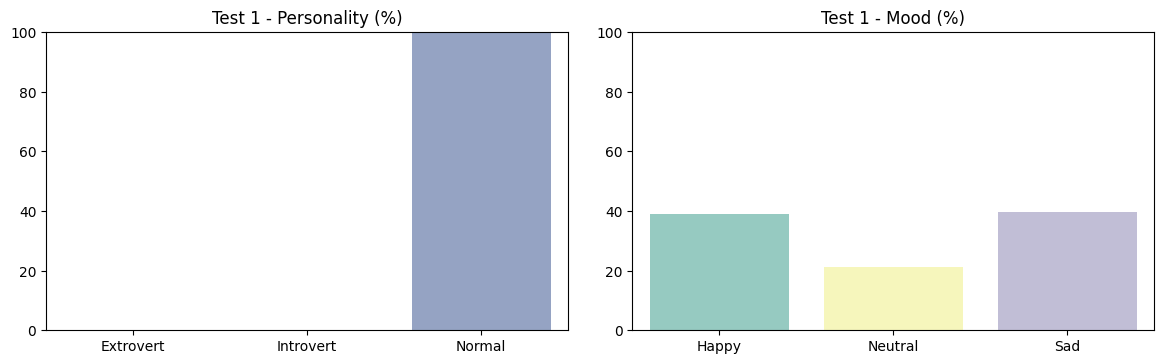


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



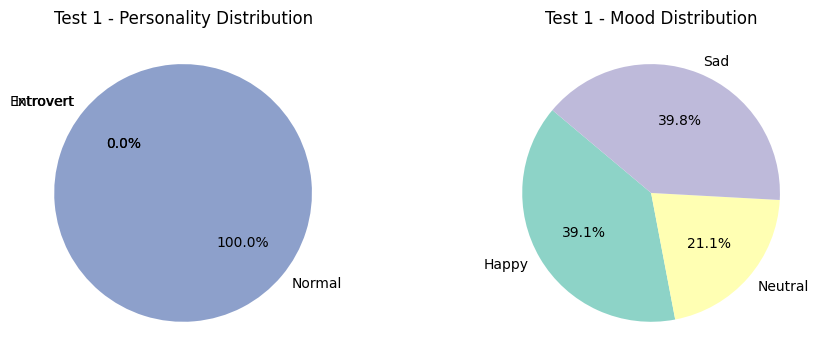


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



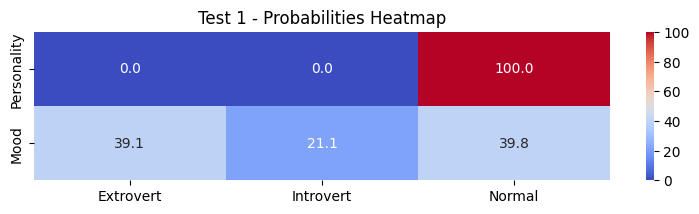


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


--- Test Case 2 ---
Predicted Personality: Extrovert (100.00% match)
Predicted Mood: Neutral (44.71% match)

Personality Probabilities:
Extrovert: 100.00%
Introvert: 0.00%
Normal: 0.00%

Mood Probabilities:
Happy: 33.79%
Neutral: 44.71%
Sad: 21.49%


<ipython-input-32-8f9c3df66217>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=le_personality.classes_, y=personality_percent, palette='Set2')
<ipython-input-32-8f9c3df66217>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=le_mood.classes_, y=mood_percent, palette='Set3')


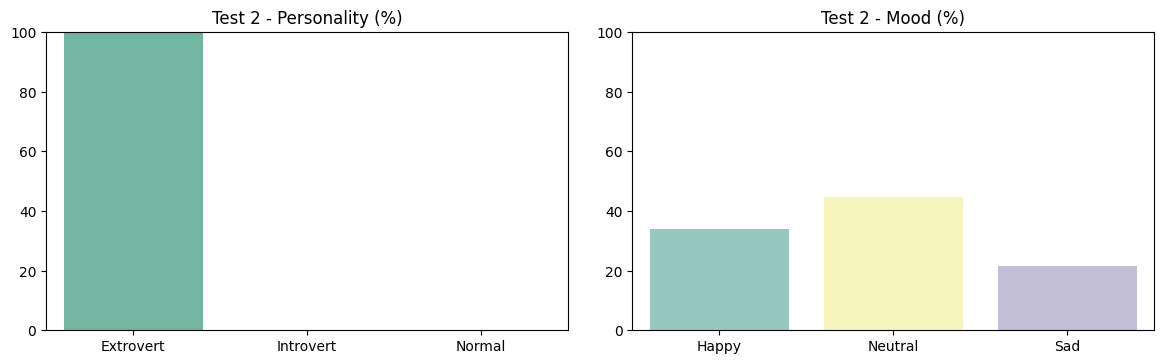


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



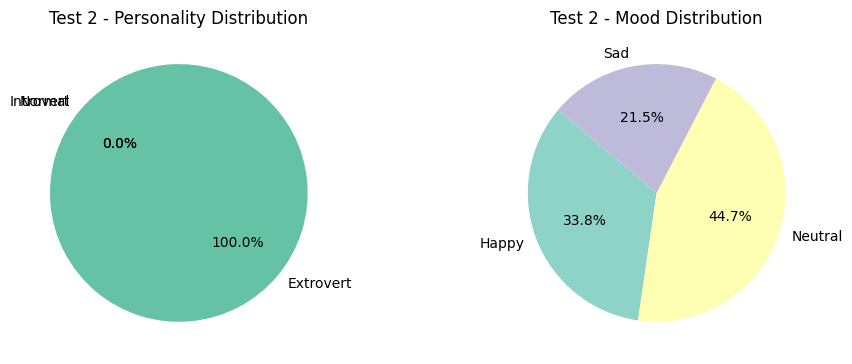


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



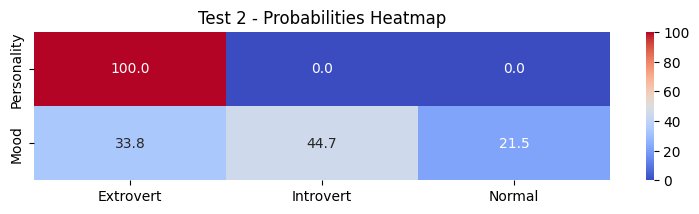


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


--- Test Case 3 ---
Predicted Personality: Introvert (100.00% match)
Predicted Mood: Sad (50.99% match)

Personality Probabilities:
Extrovert: 0.00%
Introvert: 100.00%
Normal: 0.00%

Mood Probabilities:
Happy: 17.15%
Neutral: 31.86%
Sad: 50.99%


<ipython-input-32-8f9c3df66217>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=le_personality.classes_, y=personality_percent, palette='Set2')
<ipython-input-32-8f9c3df66217>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=le_mood.classes_, y=mood_percent, palette='Set3')


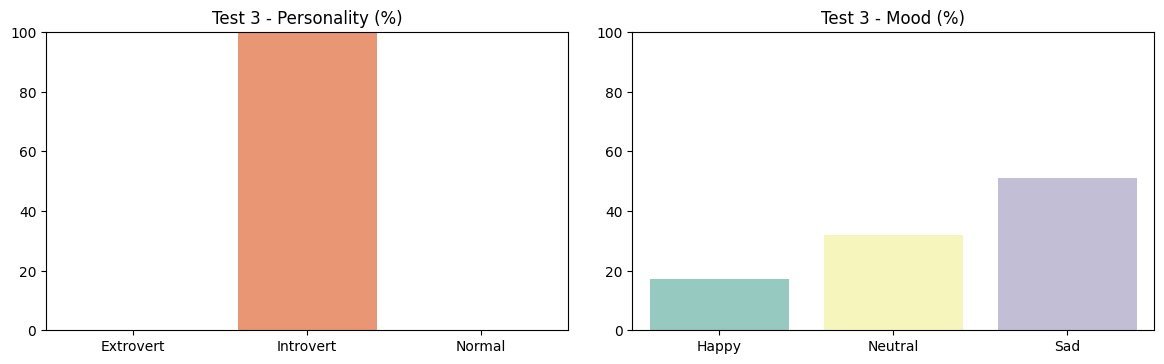


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



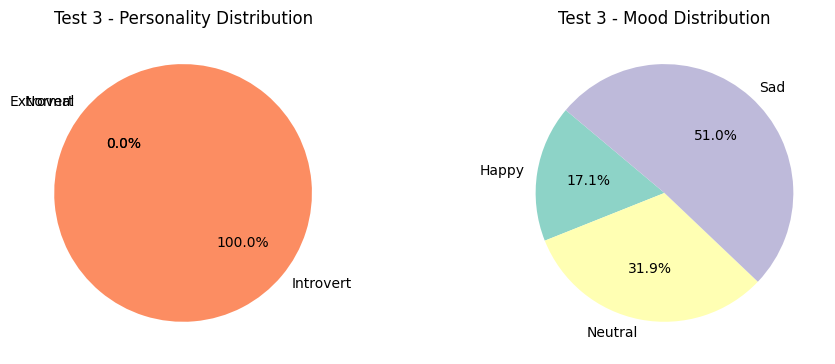


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



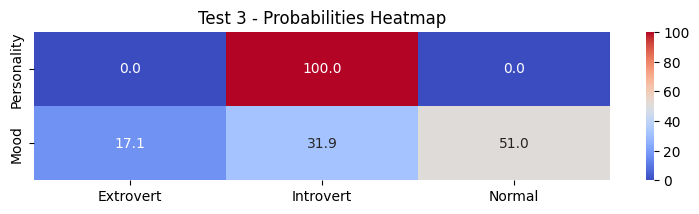


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



In [32]:
print("\n--- Running Predefined Test Cases ---")

test_users = [
    {'age': 22, 'gender': 'Female', 'likes': 1500, 'comments': 300, 'shares': 80, 'mentions': 20},
    {'age': 30, 'gender': 'Male', 'likes': 4000, 'comments': 600, 'shares': 120, 'mentions': 90},
    {'age': 19, 'gender': 'Other', 'likes': 800, 'comments': 120, 'shares': 30, 'mentions': 10}
]

for idx, user in enumerate(test_users, 1):
    print(f"\n--- Test Case {idx} ---")
    personality, mood, personality_percent, mood_percent = predict_user(
        user['age'], user['gender'], user['likes'], user['comments'], user['shares'], user['mentions'])

    personality_match = personality_percent[np.argmax(personality_percent)]
    mood_match = mood_percent[np.argmax(mood_percent)]

    print(f"Predicted Personality: {personality} ({personality_match:.2f}% match)")
    print(f"Predicted Mood: {mood} ({mood_match:.2f}% match)")

    print("\nPersonality Probabilities:")
    for label, percent in zip(le_personality.classes_, personality_percent):
        print(f"{label}: {percent:.2f}%")

    print("\nMood Probabilities:")
    for label, percent in zip(le_mood.classes_, mood_percent):
        print(f"{label}: {percent:.2f}%")

    # Plot 1: Bar Charts
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.barplot(x=le_personality.classes_, y=personality_percent, palette='Set2')
    plt.title(f"Test {idx} - Personality (%)")
    plt.ylim(0, 100)

    plt.subplot(1, 2, 2)
    sns.barplot(x=le_mood.classes_, y=mood_percent, palette='Set3')
    plt.title(f"Test {idx} - Mood (%)")
    plt.ylim(0, 100)
    plt.tight_layout(pad=2)
    plt.show()
    print("\n" + "-"*200 + "\n")

    # Pie Charts
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    axs[0].pie(personality_percent, labels=le_personality.classes_, autopct='%1.1f%%',
               startangle=140, colors=sns.color_palette("Set2"))
    axs[0].set_title(f"Test {idx} - Personality Distribution")

    axs[1].pie(mood_percent, labels=le_mood.classes_, autopct='%1.1f%%',
               startangle=140, colors=sns.color_palette("Set3"))
    axs[1].set_title(f"Test {idx} - Mood Distribution")

    plt.tight_layout(pad=2)
    plt.show()
    print("\n" + "-"*200 + "\n")


    # Prediction Probabilities Heatmap
    prob_matrix = np.array([personality_percent, mood_percent])
    labels = ['Personality', 'Mood']
    common_len = min(len(le_personality.classes_), len(le_mood.classes_))
    common_classes = le_personality.classes_[:common_len]  # Assuming label alignment

    plt.figure(figsize=(8, 2.5))
    sns.heatmap(prob_matrix[:, :common_len], annot=True, cmap="coolwarm", fmt=".1f",
                xticklabels=common_classes, yticklabels=labels)
    plt.title(f"Test {idx} - Probabilities Heatmap")
    plt.tight_layout(pad=2)
    plt.show()

    print("\n" + "-"*200 + "\n")



--- Enter User Details for Prediction ---
Enter Age: 30
Enter Gender (Male/Female/Other): Male
Enter Likes per Post: 400
Enter Comments per Post: 500
Enter Shares per Post: 300
Enter Mentions per Post: 200

--- Prediction for Input User ---

Predicted Personality: Extrovert (66.67% match)
Predicted Mood: Sad (56.50% match)

Personality Probabilities:
Extrovert: 66.67%
Introvert: 11.67%
Normal: 21.67%

Mood Probabilities:
Happy: 24.00%
Neutral: 19.50%
Sad: 56.50%


<ipython-input-41-cdce361ebc03>:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=le_personality.classes_, x=personality_percent,
<ipython-input-41-cdce361ebc03>:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=le_mood.classes_, x=mood_percent,


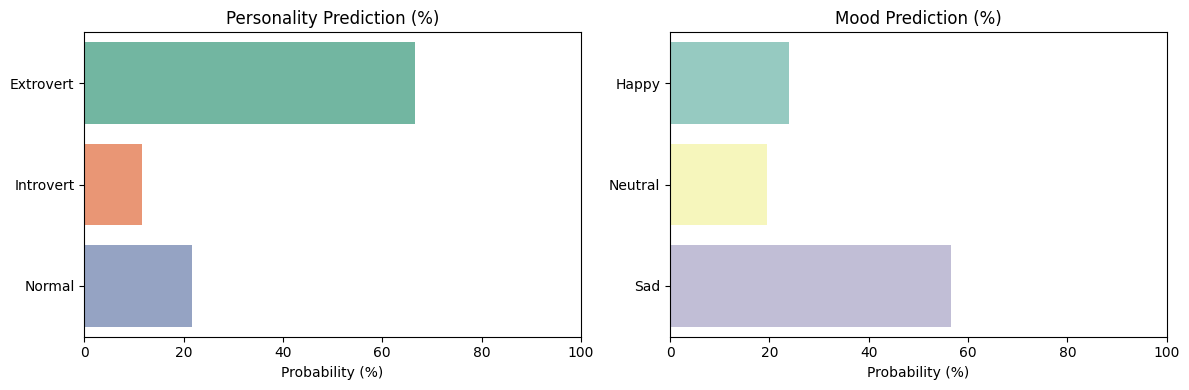


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



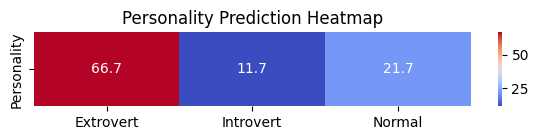

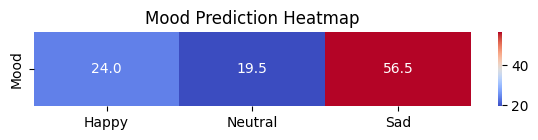


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



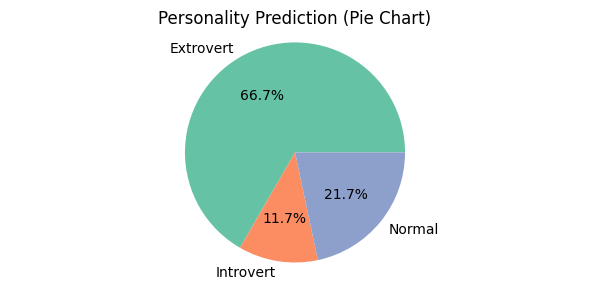


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



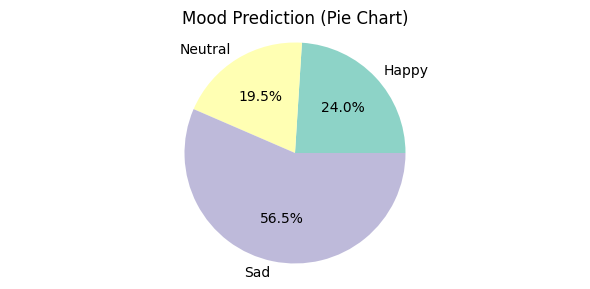

In [41]:
try:
    # --- User Input Section ---
    print("\n--- Enter User Details for Prediction ---")
    age = int(input("Enter Age: "))
    gender = input("Enter Gender (Male/Female/Other): ").strip().capitalize()
    likes = int(input("Enter Likes per Post: "))
    comments = int(input("Enter Comments per Post: "))
    shares = int(input("Enter Shares per Post: "))
    mentions = int(input("Enter Mentions per Post: "))

    # Validate gender input
    if gender not in ['Male', 'Female', 'Other']:
        raise ValueError("Invalid gender. Please enter Male, Female, or Other.")

    # --- Prediction Logic ---
    print("\n--- Prediction for Input User ---")
    personality, mood, personality_percent, mood_percent = predict_user(
        age, gender, likes, comments, shares, mentions
    )

    personality_match = personality_percent[np.argmax(personality_percent)]
    mood_match = mood_percent[np.argmax(mood_percent)]

    print(f"\nPredicted Personality: {personality} ({personality_match:.2f}% match)")
    print(f"Predicted Mood: {mood} ({mood_match:.2f}% match)")

    print("\nPersonality Probabilities:")
    for label, percent in zip(le_personality.classes_, personality_percent):
        print(f"{label}: {percent:.2f}%")

    print("\nMood Probabilities:")
    for label, percent in zip(le_mood.classes_, mood_percent):
        print(f"{label}: {percent:.2f}%")

    # --- Visualization Section ---

    # Horizontal barplots
    plt.figure(figsize=(12, 4))

    # Personality barplot
    plt.subplot(1, 2, 1)
    sns.barplot(y=le_personality.classes_, x=personality_percent,
                palette='Set2', legend=False)
    plt.title("Personality Prediction (%)")
    plt.xlabel("Probability (%)")
    plt.xlim(0, 100)

    # Mood barplot
    plt.subplot(1, 2, 2)
    sns.barplot(y=le_mood.classes_, x=mood_percent,
                palette='Set3', legend=False)
    plt.title("Mood Prediction (%)")
    plt.xlabel("Probability (%)")
    plt.xlim(0, 100)

    plt.tight_layout()
    plt.show()

    print("\n" + "-"*200 + "\n")

    #  Heatmaps for Personality and Mood Probabilities

    # Personality heatmap
    plt.figure(figsize=(6, 1.5))
    sns.heatmap([personality_percent], annot=True, cmap='coolwarm', fmt=".1f",
                xticklabels=le_personality.classes_, yticklabels=["Personality"], cbar=True)
    plt.title("Personality Prediction Heatmap")
    plt.tight_layout()
    plt.show()
    #mood heatmap
    plt.figure(figsize=(6, 1.5))
    sns.heatmap([mood_percent], annot=True, cmap='coolwarm', fmt=".1f",
                xticklabels=le_mood.classes_, yticklabels=["Mood"], cbar=True)
    plt.title("Mood Prediction Heatmap")
    plt.tight_layout()
    plt.show()

    print("\n" + "-"*200 + "\n")

    #  Pie Chart for Personality Prediction
    plt.figure(figsize=(6, 3))
    plt.pie(personality_percent, labels=le_personality.classes_,
            autopct='%1.1f%%', colors=sns.color_palette('Set2'))
    plt.title("Personality Prediction (Pie Chart)")
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

    print("\n" + "-"*200 + "\n")

    #  Pie Chart for Mood Prediction
    plt.figure(figsize=(6, 3))
    plt.pie(mood_percent, labels=le_mood.classes_,
            autopct='%1.1f%%', colors=sns.color_palette('Set3'))
    plt.title("Mood Prediction (Pie Chart)")
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")
